In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
import matplotlib.pyplot as plt
import numpy as np


font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':11
   }

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
chi_shift_pre_vs_unb_df=pd.read_csv('../../../data/dihedrals/rotamer_shift/SIDECHAIN_ROTAMER_SHIFT_PRE_VS_UNB.csv',
                                   index_col=0)
chi_shift_pre_vs_bnd_df=pd.read_csv('../../../data/dihedrals/rotamer_shift/SIDECHAIN_ROTAMER_SHIFT_PRE_VS_BND.csv',
                                   index_col=0)
del chi_shift_pre_vs_unb_df["RESIDUES"]
del chi_shift_pre_vs_bnd_df["RESIDUES"]


In [3]:
chi_shift_pre_unb_all=[]

for i in chi_shift_pre_vs_unb_df.columns:
    for sh in chi_shift_pre_vs_unb_df[i]:
        chi_shift_pre_unb_all.append(sh)
        
chi_shift_pre_bnd_all=[]

for i in chi_shift_pre_vs_bnd_df.columns:
    for sh in chi_shift_pre_vs_bnd_df[i]:
        chi_shift_pre_bnd_all.append(sh)

In [4]:
chi_shift_comp_df=pd.DataFrame()
chi_shift_comp_df['pre_vs_unb']=chi_shift_pre_unb_all
chi_shift_comp_df['pre_vs_bnd']=chi_shift_pre_bnd_all

In [5]:
import scipy
# correlation between two parameters
def corr_val(a,b):
    regg=scipy.stats.linregress(a, b)
    corr=scipy.stats.pearsonr(a,b)[0]
    slope_=regg.slope
    inter=regg.intercept
    
    
    reg_=[]
    for i in a:
        reg_line=inter + (slope_ *i)
        reg_.append(reg_line)
    
    return corr, reg_

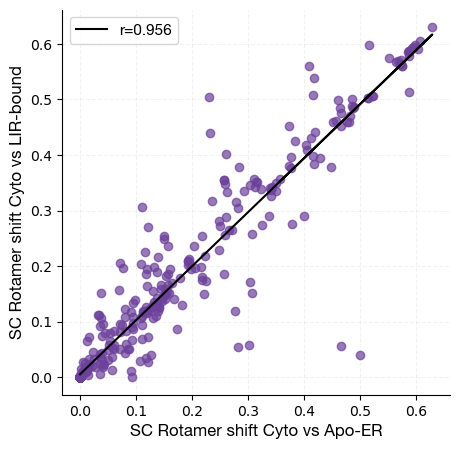

In [6]:



fig, ax = plt.subplots(figsize=(5, 5))

corr_=corr_val(chi_shift_pre_unb_all,
               chi_shift_pre_bnd_all)


ax.scatter(chi_shift_pre_unb_all,
               chi_shift_pre_bnd_all, alpha=0.7,color='#6C419B')
ax.plot(chi_shift_pre_unb_all, 
         corr_[1],color='black',
         label='r=%0.3f'%corr_[0])


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_xlabel('SC Rotamer shift Cyto vs Apo-ER', fontdict=font)
ax.set_ylabel('SC Rotamer shift Cyto vs LIR-bound', fontdict=font)

# ax.set_xlim(0,260)
# ax.set_ylim(1,14)

plt.legend(prop=rs)
plt.savefig('../../../plots/dihedrals/rotamer_shift/dihedral_sc_shift_comparison_pre_vs_unb_pre_vs_bnd.png', dpi=550,
           transparent=True, bbox_inches='tight')

In [7]:
# COMPARING CHI1 SHIFT VALUES ONLY

In [8]:
chi_shift_pre_unb_chi1_only=[]

for i in chi_shift_pre_vs_unb_df.columns[0:1]:
    for sh in chi_shift_pre_vs_unb_df[i]:
        chi_shift_pre_unb_chi1_only.append(sh)
        
chi_shift_pre_bnd_chi1_only=[]

for i in chi_shift_pre_vs_bnd_df.columns[0:1]:
    for sh in chi_shift_pre_vs_bnd_df[i]:
        chi_shift_pre_bnd_chi1_only.append(sh)

In [9]:
chi1_shift_comp_df=pd.DataFrame()
chi1_shift_comp_df['pre_vs_unb']=chi_shift_pre_unb_chi1_only
chi1_shift_comp_df['pre_vs_bnd']=chi_shift_pre_bnd_chi1_only

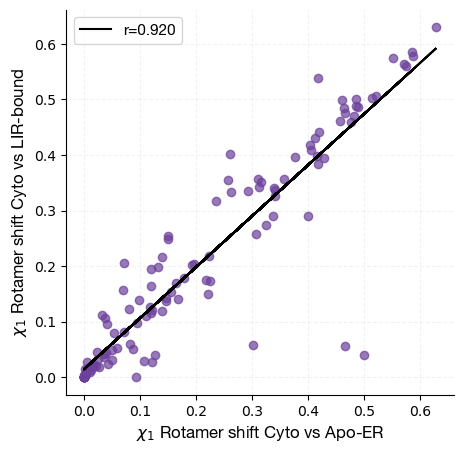

In [10]:

fig, ax = plt.subplots(figsize=(5, 5))

corr_=corr_val(chi_shift_pre_unb_chi1_only,
               chi_shift_pre_bnd_chi1_only)


ax.scatter(chi_shift_pre_unb_chi1_only,
               chi_shift_pre_bnd_chi1_only, alpha=0.7,color='#6C419B')
ax.plot(chi_shift_pre_unb_chi1_only, 
         corr_[1],color='black',
         label='r=%0.3f'%corr_[0])


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_xlabel('$\chi_1$ Rotamer shift Cyto vs Apo-ER', fontdict=font)
ax.set_ylabel('$\chi_1$ Rotamer shift Cyto vs LIR-bound', fontdict=font)

# ax.set_xlim(0,260)
# ax.set_ylim(1,14)

plt.legend(prop=rs)
plt.savefig('../../../plots/dihedrals/rotamer_shift/dihedral_CHI1_shift_comparison_pre_vs_unb_pre_vs_bnd.png', dpi=550,
           transparent=True, bbox_inches='tight')

In [11]:
#BACKBONE DIHEDRAL comparison

In [12]:
bb_shift_data_pre_vs_unb=pd.read_csv('../../../data/dihedrals/rotamer_shift/BACKBONE_ROTAMER_SHIFT_PRE_VS_UNB.csv',
                                    index_col=0)
bb_shift_data_pre_vs_bnd=pd.read_csv('../../../data/dihedrals/rotamer_shift/BACKBONE_ROTAMER_SHIFT_PRE_VS_BND.csv',
                                    index_col=0)

In [13]:
bb_shift_pre_unb_all=[]

for i in bb_shift_data_pre_vs_unb.columns[1:3]:
    for sh in bb_shift_data_pre_vs_unb[i]:
        bb_shift_pre_unb_all.append(sh)

In [14]:
bb_shift_pre_bnd_all=[]

for i in bb_shift_data_pre_vs_bnd.columns[1:3]:
    for sh in bb_shift_data_pre_vs_bnd[i]:
        bb_shift_pre_bnd_all.append(sh)

In [15]:
bb_shift_comp_df=pd.DataFrame()
bb_shift_comp_df['pre_vs_unb']=bb_shift_pre_unb_all
bb_shift_comp_df['pre_vs_bnd']=bb_shift_pre_bnd_all

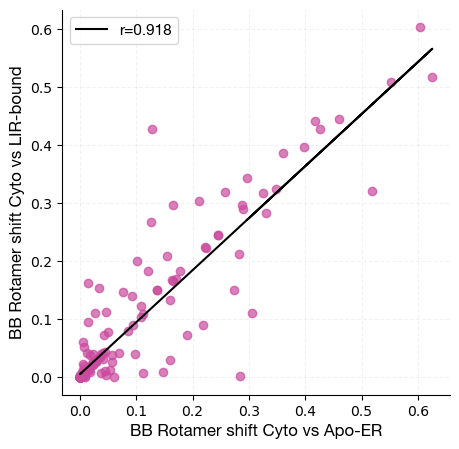

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))

corr_=corr_val(bb_shift_pre_unb_all,
               bb_shift_pre_bnd_all)


ax.scatter(bb_shift_pre_unb_all,
               bb_shift_pre_bnd_all, alpha=0.7,color='#CA4A9E')
ax.plot(bb_shift_pre_unb_all, 
         corr_[1],color='black',
         label='r=%0.3f'%corr_[0])


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_xlabel('BB Rotamer shift Cyto vs Apo-ER', fontdict=font)
ax.set_ylabel('BB Rotamer shift Cyto vs LIR-bound', fontdict=font)

# ax.set_xlim(0,260)
# ax.set_ylim(1,14)

plt.legend(prop=rs)
plt.savefig('../../../plots/dihedrals/rotamer_shift/dihedral_BB_shift_comparison_pre_vs_unb_pre_vs_bnd.png', dpi=550,
           transparent=True, bbox_inches='tight')